In [1]:
import pandas as pd 
import numpy as np 
import sys,os
sys.path.append(os.path.abspath("../"))
from src.correlation_errors import SERRF
from src.base import Preprocessor,BatchCorrectionPipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.stats import iqr
import matplotlib.pyplot as plt

In [2]:
# Outlier Function from SiliFan used to remove outlier before RSD calculation
def tukey_hinges(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = np.sort(x)

    n = len(x)
    if n == 0:
        return np.nan, np.nan

    if n % 2 == 0:
        lower = x[:n//2]
        upper = x[n//2:]
    else:
        lower = x[:n//2 + 1]
        upper = x[n//2:]

    return np.median(lower), np.median(upper)
def remove_outlier_r_style(x):
    q1, q3 = tukey_hinges(x.values)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    x_clean = x.copy()
    mask = (x.values < lower) | (x.values > upper)
    x_clean = x_clean.astype(float)
    x_clean.values[mask] = np.nan
    return x_clean


def RSD(x,remove_outlier=True):
    if remove_outlier:
        x_clean = remove_outlier_r_style(x).dropna()
    else:
        x_clean = x 
    return 100*(x_clean.std(ddof=1) / x_clean.mean())

In [3]:
datapath = r'../data/SERRF example dataset - with validate.xlsx'
data = pd.read_excel(datapath,sheet_name="Sheet1",header=0)

metadata = data.iloc[:3,1:].T.reset_index()
metadata.columns = metadata.iloc[0,:]
metadata = metadata.iloc[1:,:]
metadata['batch'] = metadata['batch'].str.replace(r'\.\d+',"",regex=True)
metadata = metadata.set_index("label")
# Number duplicate labels to make them unique (sample01 -> sample01_0, sample01_1, ...)
label_series = metadata.index.to_series()
metadata.index = label_series + '_' + label_series.groupby(label_series).cumcount().astype(str)

data = data.iloc[2:,1:].T
data.columns = data.iloc[0,:]
data = data.drop(index='batch')
data.columns.name = None
data = data.reset_index(drop=True)
data = data.set_index('label')
data.index = metadata.index
data = data.apply(pd.to_numeric,errors='coerce')
data.columns = [f'MET{x}' for x in range(len(data.columns))]

In [4]:
pipeline = BatchCorrectionPipeline(
    method=SERRF(qc_str='QC',blank_str="blank",use_ranger=True),
    preprocessing_config=Preprocessor(imputation_method=None,normalization_method=None,transformation_method=None)
)
data_qc = data[data.index.str.contains("QC")]
data_1 = data[metadata['sampleType'] != "validate"]
metadata_1 = metadata[metadata['sampleType'] != "validate"].copy()
results = pipeline.correct(data=data_1,metadata=metadata_1)

data_validate = data.loc[(metadata['sampleType'] == "validate") | (metadata['sampleType'] == "qc")]
metadata_validate = metadata.loc[data_validate.index,:]
results_validate = pipeline.correct(data=data_validate,metadata=metadata_validate)

## Cross Validation 
#cv1 = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120,125]
#cv2 = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76,81,86,91,96,101,106,111,116,121]
#cv3 = [2,7,12,17,22,27,32,37,42,47,52,57,62,67,72,77,82,87,92,97,102,107,112,117,122]
#cv4 = [3,8,13,18,23,28,33,38,43,48,53,58,63,68,73,78,83,88,93,98,103,108,113,118,123]


None
Initailzing Models
Computing Correlation Matrix [A/4]
Selecting Top Correlated Features: [A/4]


	 Buliding models for batch A: 100%|██████████| 268/268 [00:09<00:00, 27.72it/s]


Computing Correlation Matrix [B/4]
Selecting Top Correlated Features: [B/4]


	 Buliding models for batch B: 100%|██████████| 268/268 [00:07<00:00, 36.08it/s]


Computing Correlation Matrix [C/4]
Selecting Top Correlated Features: [C/4]


...

Computing Correlation Matrix [C/4]
Selecting Top Correlated Features: [C/4]


	 Buliding models for batch C: 100%|██████████| 268/268 [00:04<00:00, 53.70it/s]


Computing Correlation Matrix [D/4]
Selecting Top Correlated Features: [D/4]


	 Buliding models for batch D: 100%|██████████| 268/268 [00:04<00:00, 54.82it/s]


Normalizing All batches


# 1-PCA

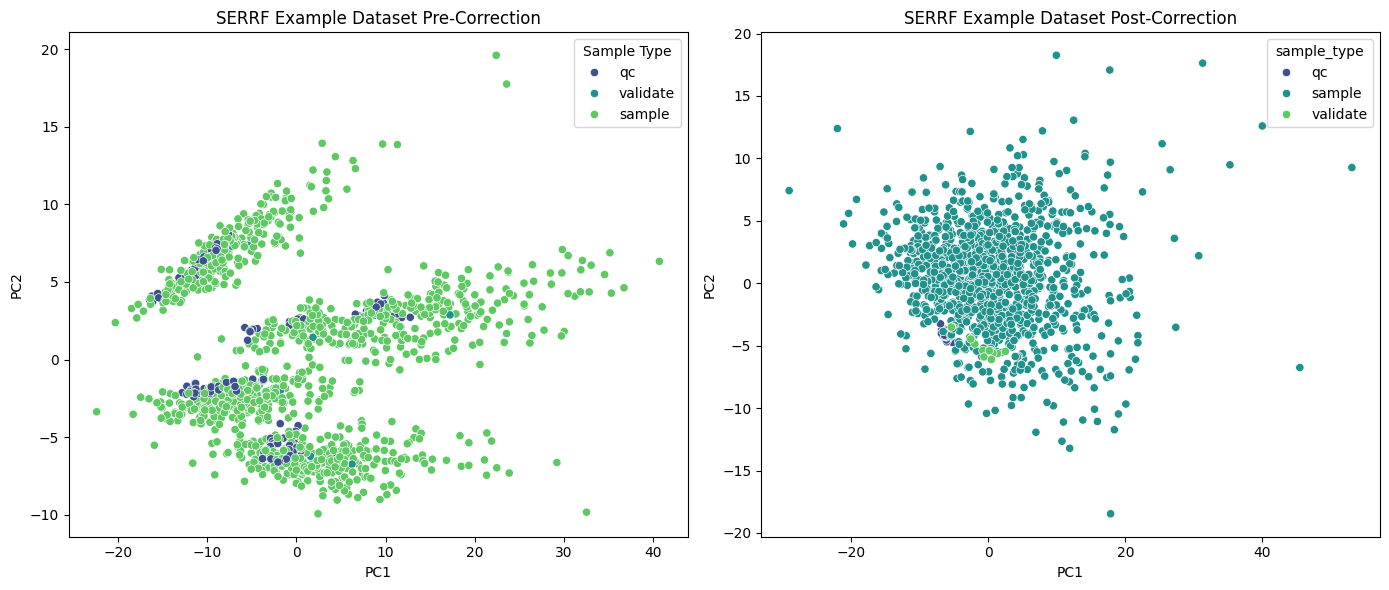

In [5]:
pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(StandardScaler().fit_transform(data)),columns=["PC1","PC2"],index=data.index)
pca_df['sample_type'] = metadata['sampleType']


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(
    data=pca_df, 
    x='PC1', y='PC2',
    hue='sample_type',
    palette='viridis',
    ax=axes[0]  # specify subplot
)
axes[0].set_title("SERRF Example Dataset Pre-Correction")



# Perform PCA
df = pd.concat([results, results_validate[~results_validate.index.str.contains("QC")]])
pca = PCA(n_components=2)
scores = pca.fit_transform(StandardScaler().fit_transform(df))

# Flip PC2 (flip the second column, not second row)
scores[:, 1] *= -1  # This flips all rows in the PC2 column
pca.components_[1, :] *= -1  # This flips the loadings

# Create DataFrame with flipped scores
pca_df = pd.DataFrame(scores, columns=['PC1', 'PC2'], index=df.index)
pca_df['sample_type'] = metadata['sampleType']
# ----- Right subplot: Post-Correction -----
sns.scatterplot(
    data=pca_df, 
    x='PC1', y='PC2',
    hue='sample_type',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("SERRF Example Dataset Post-Correction")

# Optional: remove duplicate legends
#axes[1].legend_.remove()  # if you want only one legend
axes[0].legend(title='Sample Type')

plt.tight_layout()
plt.show()

# 2-QC and Validate RSDs

In [6]:
# QC RSD (Pre-Correction)
qc_pre = data.loc[metadata['sampleType'] == "qc"].apply(RSD,axis=0).median()

# QC RSD (Post-Correction)
qc_post = results.loc[metadata['sampleType'] == "qc"].apply(RSD,axis=0).median()

# Sample RSD (Pre-Correction)
sample_pre = data.loc[metadata['sampleType'] == "sample"].apply(RSD,axis=0).median()

# Sample RSD (Post-Correction)
sample_post = results.loc[metadata['sampleType'] == "sample"].apply(RSD,axis=0).median()

# Validate RSD (Pre-Correction)
validate_pre = data.loc[metadata['sampleType'] == "validate"].apply(RSD,axis=0).median()

# Validate RSD (Post-Correction)
validate_post = results_validate.loc[metadata['sampleType'] == "validate"].apply(RSD,axis=0).median()

In [13]:
R_before = pd.read_excel(r"../data/SERRF example dataset - with validate.xlsx",header=0)
R_metadata = R_before.iloc[:4,:].drop(columns=["Unnamed: 0"]).T.drop(columns=3)
R_metadata.columns = R_metadata.iloc[0,:]
R_metadata = R_metadata.drop(index='batch')
R_metadata = R_metadata.set_index('label')
label_series = R_metadata.index.to_series()
R_metadata.index = label_series + '_' + label_series.groupby(label_series).cumcount().astype(str)

R_before = pd.read_excel(r"../data/SERRF example dataset - with validate.xlsx",header=3)
R_before = R_before.drop(columns=['No'])
R_before = R_before.set_index("label").T
R_before.columns = [f"MET{x}" for x in range(len(R_before.columns))]
R_before.index = R_before.index.str.replace(r'\.\d+$', '', regex=True)
label_series = R_before.index.to_series()
R_before.index = label_series + '_' + label_series.groupby(label_series).cumcount().astype(str)

R_after = pd.read_csv(r'../data/SERRF Result/normalized by - SERRF.csv')
R_after = R_after.set_index("label").T
R_after.columns = [f"MET{x}" for x in range(len(R_after.columns))]
R_after.index = R_after.index.str.replace(r'\.\d+$', '', regex=True)
label_series = R_after.index.to_series()
R_after.index = label_series + '_' + label_series.groupby(label_series).cumcount().astype(str)

In [14]:
rqc_before = R_before[R_before.index.str.contains('QC')]
rqc_after = R_after[R_after.index.str.contains("QC")]
validate_names = R_metadata[R_metadata['sampleType'] == 'validate'].index
validate_pattern = "|".join(validate_names.unique())
rsample_before = R_before[~R_before.index.str.contains('QC') & ~R_before.index.str.contains(validate_pattern)]
rsample_after = R_after[~R_after.index.str.contains('QC') & ~R_after.index.str.contains(validate_pattern)]
rvalidate_before = R_before[R_before.index.str.contains(validate_pattern)]
rvalidate_after = R_after[R_after.index.str.contains(validate_pattern)]
rqc_before = rqc_before.apply(RSD,axis=0).median()
rqc_after = rqc_after.apply(RSD,axis=0).median()
rsample_before = rsample_before.apply(RSD,axis=0).median()
rsample_after = rsample_after.apply(RSD,axis=0).median()
rvalidate_before = rvalidate_before.apply(RSD,axis=0).median()
rvalidate_after = rvalidate_after.apply(RSD,axis=0).median()
py_results = pd.concat([results,results_validate[R_metadata['sampleType'] == 'validate']])
df1 = pd.DataFrame({"QC":[qc_pre,qc_post],"Sample":[sample_pre,sample_post],"Validate":[validate_pre,validate_post]},index=["Pre-Correction","Post-Correction"])
df2 = pd.DataFrame({"QC":[rqc_before,rqc_after],"Sample":[rsample_before,rsample_after],"Validate":[rvalidate_before,rvalidate_after]},index=['Pre-Correction','Post-Correction'])

/var/folders/qr/rs4_by9j19b010f7x4kmcs400000gn/T/ipykernel_98449/722287875.py:15: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [15]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go 

fig = make_subplots(rows=1,cols=6,subplot_titles=("Python QC-RSDs","R QC-RSDs","Python Validate-RSDs","R Validate-RSDs","R Sample-RSDs", "R Sample-RSDs"))

fig.add_trace(go.Bar(x=['Pre-Correction',"Post-Correction"],y=df1['QC'],text=np.round(df1['QC'].values,2)), row=1, col=1)
fig.add_trace(go.Bar(x=['Pre-Correction',"Post-Correction"],y=df2['QC'],text=np.round(df2['QC'].values,2)), row=1, col=2)

fig.add_trace(go.Bar(x=['Pre-Correction',"Post-Correction"],y=df1['Validate'],text=np.round(df1['Validate'].values,2)), row=1, col=3)
fig.add_trace(go.Bar(x=['Pre-Correction',"Post-Correction"],y=df2['Validate'],text=np.round(df2['Validate'].values,2)), row=1, col=4)

fig.add_trace(go.Bar(x=['Pre-Correction',"Post-Correction"],y=df1['Sample'],text=np.round(df2['Sample'].values,2)), row=1, col=5)
fig.add_trace(go.Bar(x=['Pre-Correction',"Post-Correction"],y=df1['Sample'],text=np.round(df2['Sample'].values,2)), row=1, col=6)

fig.update_traces(textposition='outside')
fig.update_layout(height=600, width=1200, title_text="SERRF Validation - Median RSD for QC (125), Sample (1162), and Validation Sets (12)")

# 3-Pearson Correlation Analysis

In [16]:
pyqc_after = py_results[py_results.index.str.contains("QC")]
rqc_after = R_after[R_after.index.str.contains("QC")]

py_validate_after = py_results[metadata['sampleType'] == 'validate']
r_validate_after = R_after[metadata['sampleType'] == 'validate']

py_biological_after = py_results[metadata['sampleType'] == 'sample']
r_biological_after = R_after[R_metadata['sampleType'] == 'sample']

/var/folders/qr/rs4_by9j19b010f7x4kmcs400000gn/T/ipykernel_98449/3010883667.py:4: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/var/folders/qr/rs4_by9j19b010f7x4kmcs400000gn/T/ipykernel_98449/3010883667.py:7: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



0.9938012956879987
0.9933196011895025
0.9824614363517028
0.9997780784098671
0.9979045743498463
0.8790786388147093


Text(0.5, 1.0, 'Pearson Correlation Between R and Python SERRF Results (Biological Samples) \nMedian Correlation:1.0\nMean Correlation:1.0')

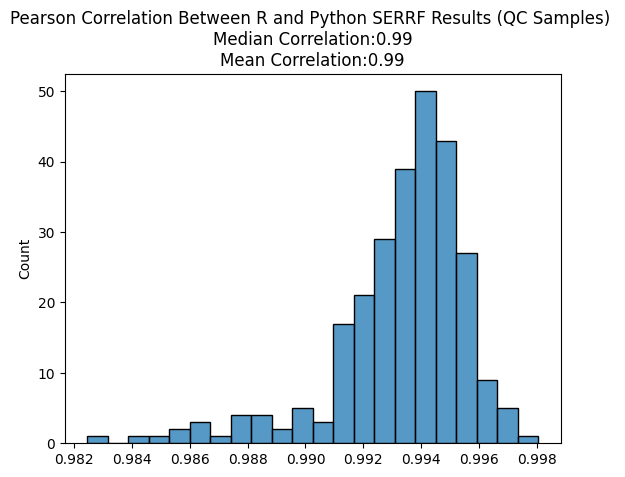

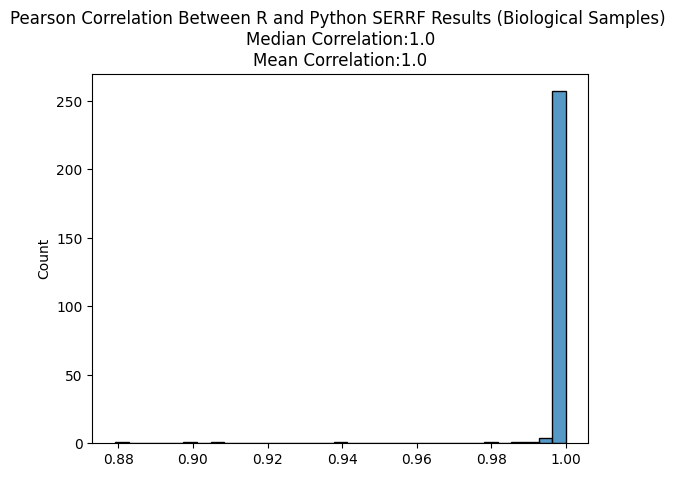

In [17]:
corrsqc = []
for col in rqc_after.columns:
    corr = rqc_after[col].corr(pyqc_after[col],method='pearson')
    corrsqc.append(corr)

corrsqc = np.asarray(corrsqc)
print(np.median(corrsqc))
print(np.mean(corrsqc))
print(np.min(corrsqc))
import seaborn as sns
sns.histplot(corrsqc)
plt.title(f"Pearson Correlation Between R and Python SERRF Results (QC Samples) \nMedian Correlation:{np.round(np.median(corrsqc),2)}\nMean Correlation:{np.round(np.mean(corrsqc),2)}")


plt.figure()
corrs_biological = []
for col in R_after.columns:
    corr = r_biological_after[col].corr(py_biological_after[col],method='pearson')
    corrs_biological.append(corr)

corrs_biological = np.asarray(corrs_biological)
print(np.median(corrs_biological))
print(np.mean(corrs_biological))
print(np.min(corrs_biological))

sns.histplot(corrs_biological)
plt.title(f"Pearson Correlation Between R and Python SERRF Results (Biological Samples) \nMedian Correlation:{np.round(np.median(corrs_biological),2)}\nMean Correlation:{np.round(np.mean(corrs_biological),2)}")

# 4-Concordance Correlation Coefficient

In [23]:
from torchmetrics import ConcordanceCorrCoef
import torch
ccc = ConcordanceCorrCoef()

Text(0.5, 1.0, 'Concordance Correlation Coefficient Distribution (Biological Samples) \n Median:[1.] Mean: [1.]')

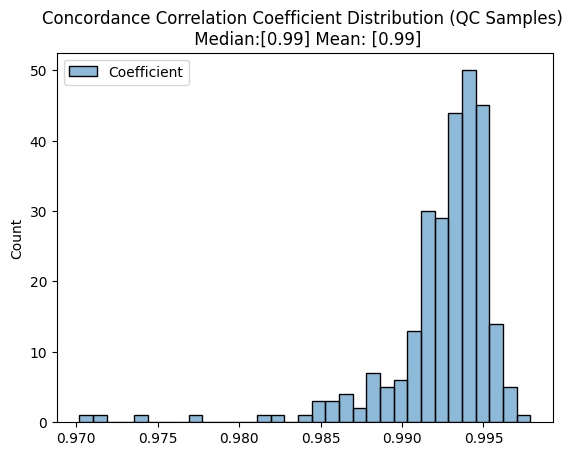

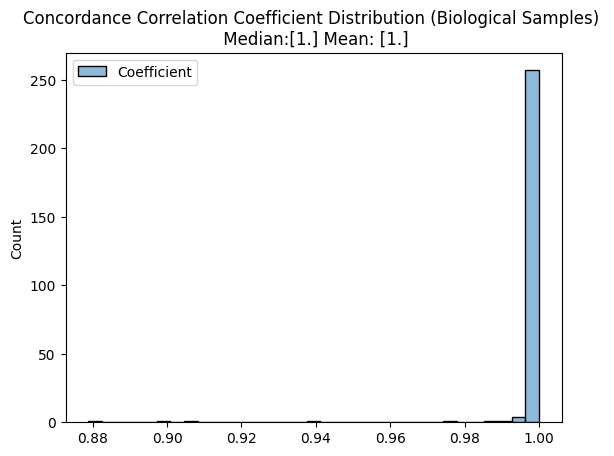

In [24]:
concordanceqc = []
for col in rqc_after.columns:
   i = (torch.tensor(rqc_after[col].to_numpy()))
   j = (torch.tensor(pyqc_after[col].to_numpy()))
   con = ccc(i,j)
   #print(f'{col}:{con}')
   concordanceqc.append(con)
concordanceqc = np.asarray(concordanceqc)

concordanceqc = pd.DataFrame(concordanceqc,columns=['Coefficient'])

fig = sns.histplot(concordanceqc)
plt.title(f"Concordance Correlation Coefficient Distribution (QC Samples) \n Median:{np.round(concordanceqc.median().values,2)} Mean: {np.round(concordanceqc.mean(),2).values}")


plt.figure()
concordance_biological = []
for col in R_after.columns:
   i = (torch.tensor(r_biological_after[col].to_numpy()))
   j = (torch.tensor(py_biological_after[col].to_numpy()))
   con = ccc(i,j)
   #print(f'{col}:{con}')
   concordance_biological.append(con)
concordance_biological = np.asarray(concordance_biological)

concordance_biological = pd.DataFrame(concordance_biological,columns=['Coefficient'])

fig = sns.histplot(concordance_biological)
plt.title(f"Concordance Correlation Coefficient Distribution (Biological Samples) \n Median:{np.round(concordance_biological.median().values,2)} Mean: {np.round(concordance_biological.mean(),2).values}")

# 5-Percent Error

Text(0.5, 1.0, 'Percent Error Distribution (Biological Samples)\nMedian:[0.39] Mean: [0.58]')

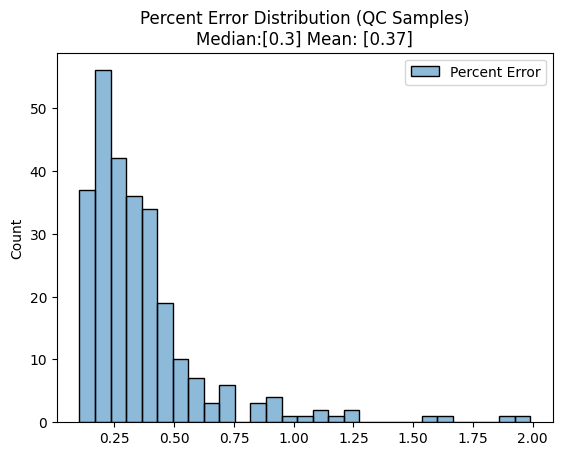

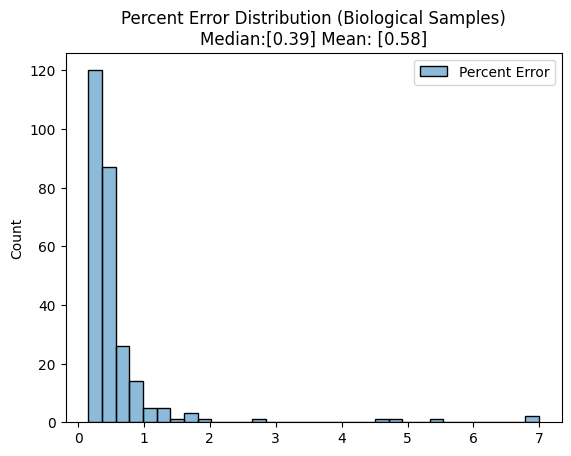

In [25]:
def percent_difference(py, r):
    out = np.abs(py - r) / np.abs(r) * 100
    return out
store = {}
for col in rqc_after.columns:
    x = rqc_after[col]
    y = pyqc_after[col]
    store[col] = percent_difference(x,y).mean()

percent_error_qc = pd.DataFrame({i:j for i,j in store.items()},index=['Percent Error']).T
sns.histplot(percent_error_qc)
plt.title(f"Percent Error Distribution (QC Samples)\nMedian:{np.round(percent_error_qc.median().values,2)} Mean: {np.round(percent_error_qc.mean(),2).values}")

plt.figure()
store = {}
for col in rqc_after.columns:
    x = r_biological_after[col]
    y = py_biological_after[col]
    store[col] = percent_difference(x,y).mean()

percent_error_biological = pd.DataFrame({i:j for i,j in store.items()},index=['Percent Error']).T
sns.histplot(percent_error_biological)
plt.title(f"Percent Error Distribution (Biological Samples)\nMedian:{np.round(percent_error_biological.median().values,2)} Mean: {np.round(percent_error_biological.mean(),2).values}")

# 6-Outlier Evaluation

In [26]:
# Correlation
def plot_correlation_outlier(corrs, py_data, r_data, pearson=None, concordance=None, percent_error=None, method="Correlation", label="QC", threshold=None, alternative='greater'):
    """Plot scatter + distribution for outlier metabolites, reporting all three metrics."""
    corrs_flat = np.asarray(corrs).flatten()
    pearson_flat = np.asarray(pearson).flatten() if pearson is not None else None
    concordance_flat = np.asarray(concordance).flatten() if concordance is not None else None
    pe_flat = np.asarray(percent_error).flatten() if percent_error is not None else None

    if threshold is not None:
        outlier_idxs = np.where(corrs_flat < threshold)[0]
        outlier_idxs = np.hstack([outlier_idxs,np.where(pearson_flat < threshold)[0]])
        outlier_idxs = np.hstack([outlier_idxs,np.where(concordance_flat < threshold)[0]])
        outlier_idxs = np.hstack([outlier_idxs,np.where(pe_flat > 5)[0]])
        outlier_idxs = np.unique(outlier_idxs)
    else:
        outlier_idxs = [int(np.argmin(corrs_flat))]

    for idx in outlier_idxs:
        met = f"MET{idx}"

        # Build metric summary string
        metrics_parts = []
        if pearson_flat is not None:
            metrics_parts.append(f"Pearson: {float(pearson_flat[idx]):.4f}")
        if concordance_flat is not None:
            metrics_parts.append(f"CCC: {float(concordance_flat[idx]):.4f}")
        if pe_flat is not None:
            metrics_parts.append(f"% Error: {float(pe_flat[idx]):.2f}%")
        metrics_str = " | ".join(metrics_parts)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"Metric Evaluation: {label} Feature Outlier: {met}\n{metrics_str}")

        axes[0].scatter(py_data[met], r_data[met])
        axes[0].set_xlabel("Python")
        axes[0].set_ylabel("R")
        axes[0].set_title("R vs Python Intensity")

        r_std = np.round(r_data[met].std(), 2)
        r_mean = np.round(r_data[met].mean(), 2)
        sns.histplot(py_data[met], label="Python", ax=axes[1])
        sns.histplot(r_data[met], label="R", ax=axes[1])
        axes[1].set_title(f"Intensity Distribution | Std: {r_std} | Mean: {r_mean}")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

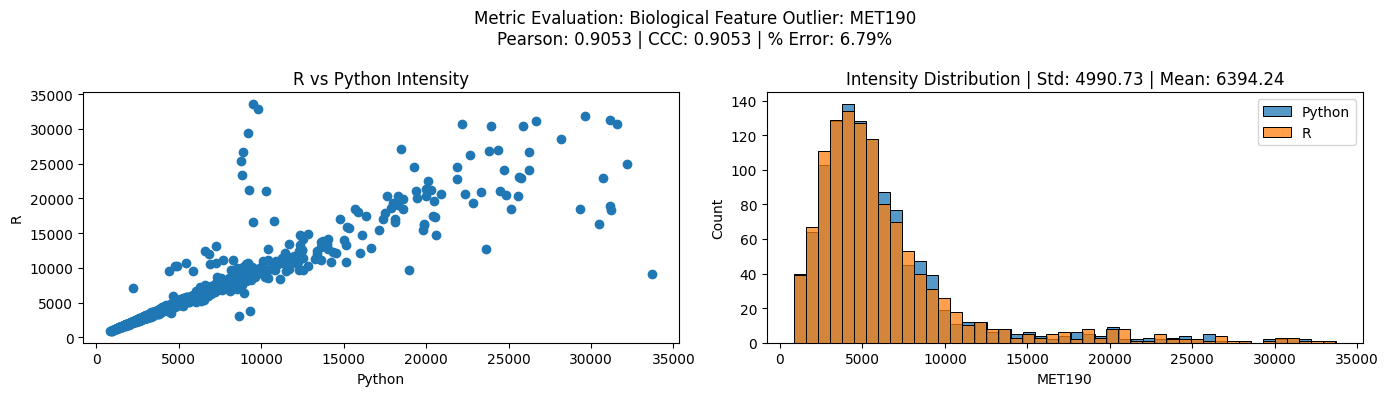

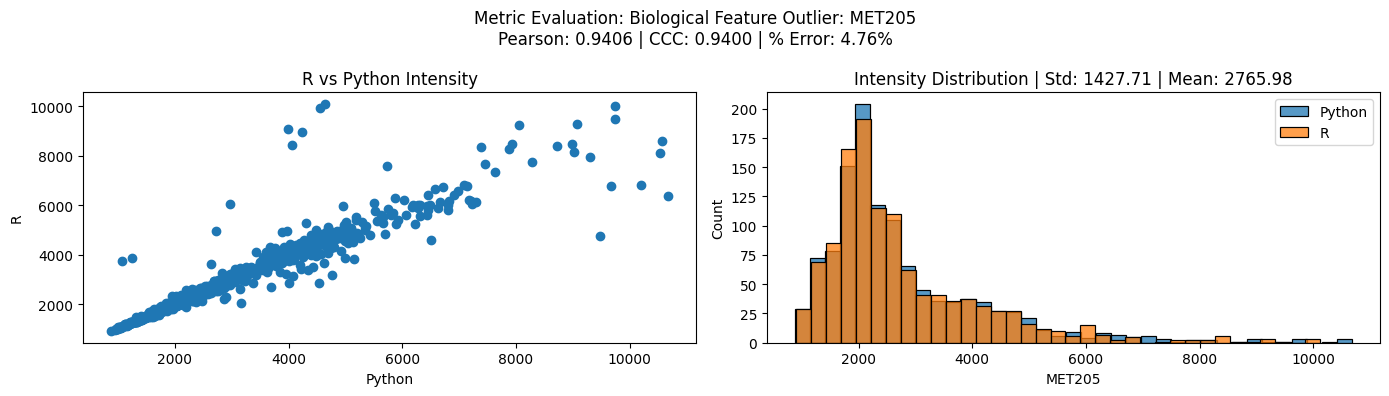

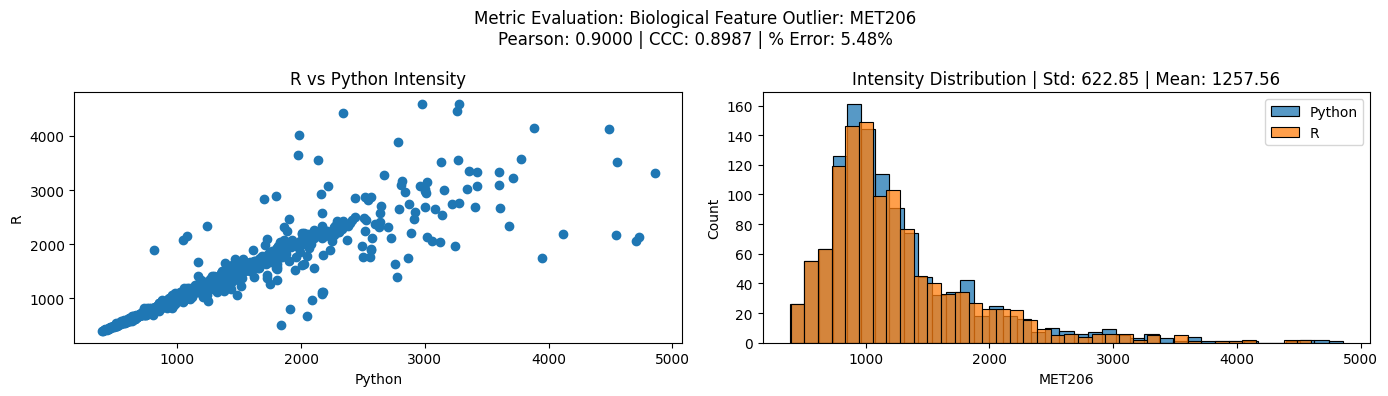

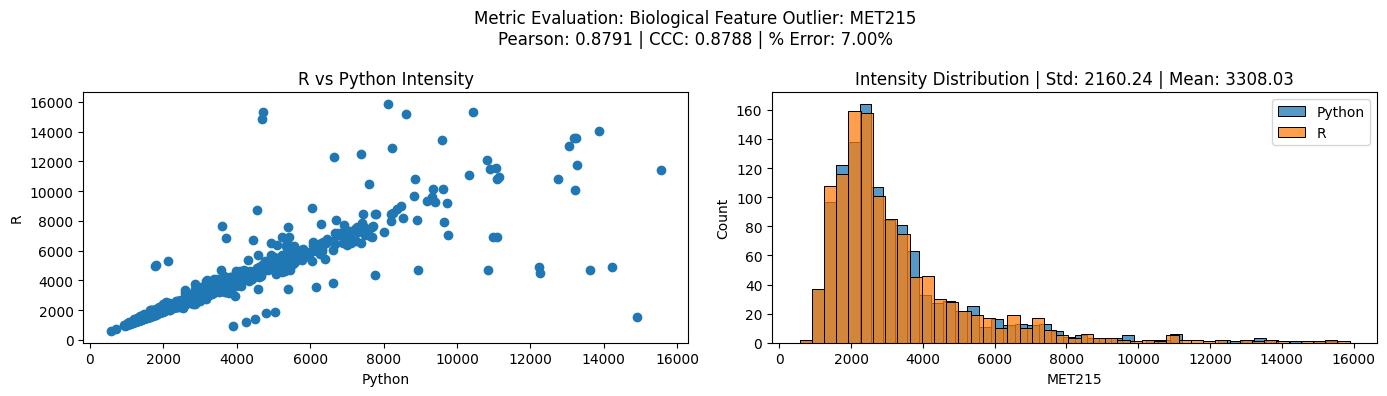

In [27]:
plot_correlation_outlier(corrsqc, pyqc_after, rqc_after, pearson=corrsqc, concordance=concordanceqc, percent_error=percent_error_qc, method="Pearson Correlation", label="QC", threshold=.95, alternative='lesser')
plot_correlation_outlier(corrs_biological, py_biological_after, r_biological_after, pearson=corrs_biological, concordance=concordance_biological,percent_error=percent_error_biological,method='Pearson Correlation',label='Biological',threshold=.95,alternative='lesser')

In [31]:
# Concordance
outlier_ids = np.where(concordanceqc < 0.95)[0]
outlier_ids = np.unique(np.hstack([outlier_ids,np.where(concordance_biological < 0.95)[0]]))
print(f"Metabolites with concordance < 0.95: {outlier_ids}")

Metabolites with concordance < 0.95: [190 205 206 215]


In [32]:
# Percent Error
outlier_ids = np.where(percent_error_qc > 5)[0]
outlier_ids = np.unique(np.hstack([outlier_ids,np.where(percent_error_biological >  5)[0]]))
print(f"Metabolites with Percent Error > 5: {outlier_ids}")

Metabolites with Percent Error > 5: [190 206 215]
